
First 5 rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Missing Values:
Region                                     28
Dat

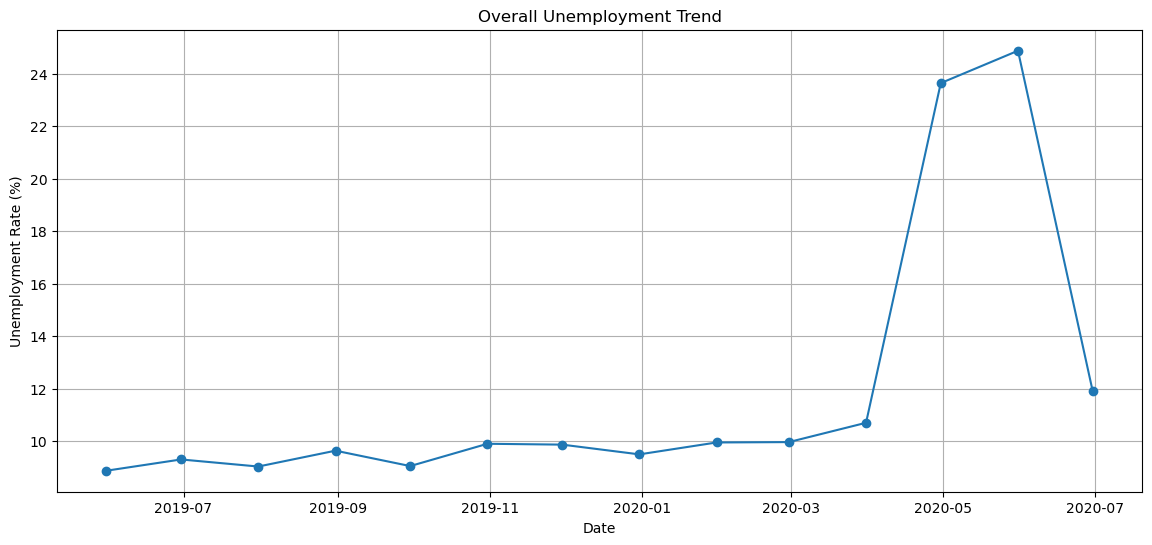

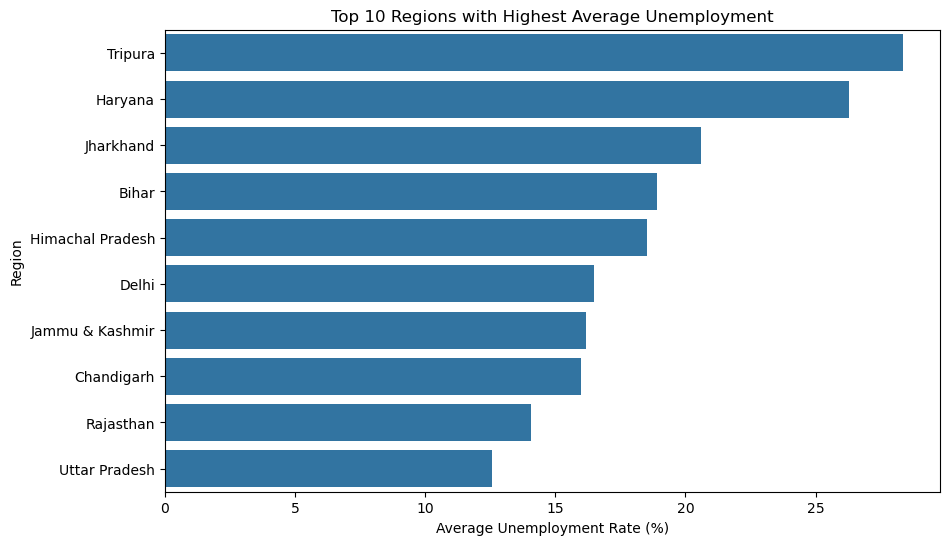

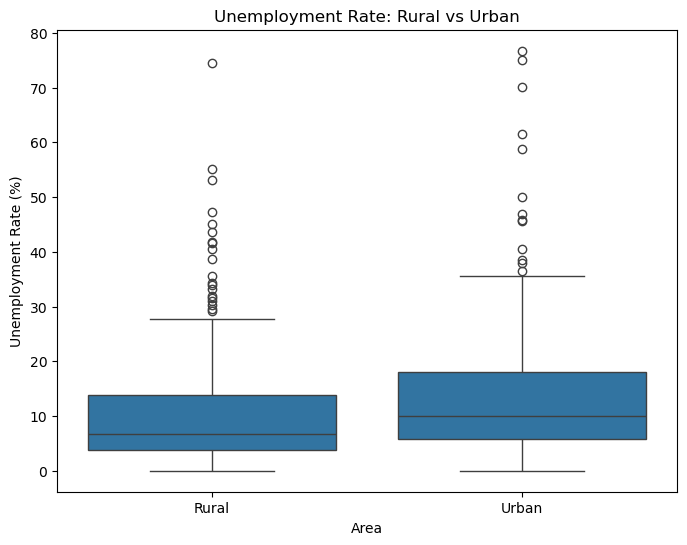

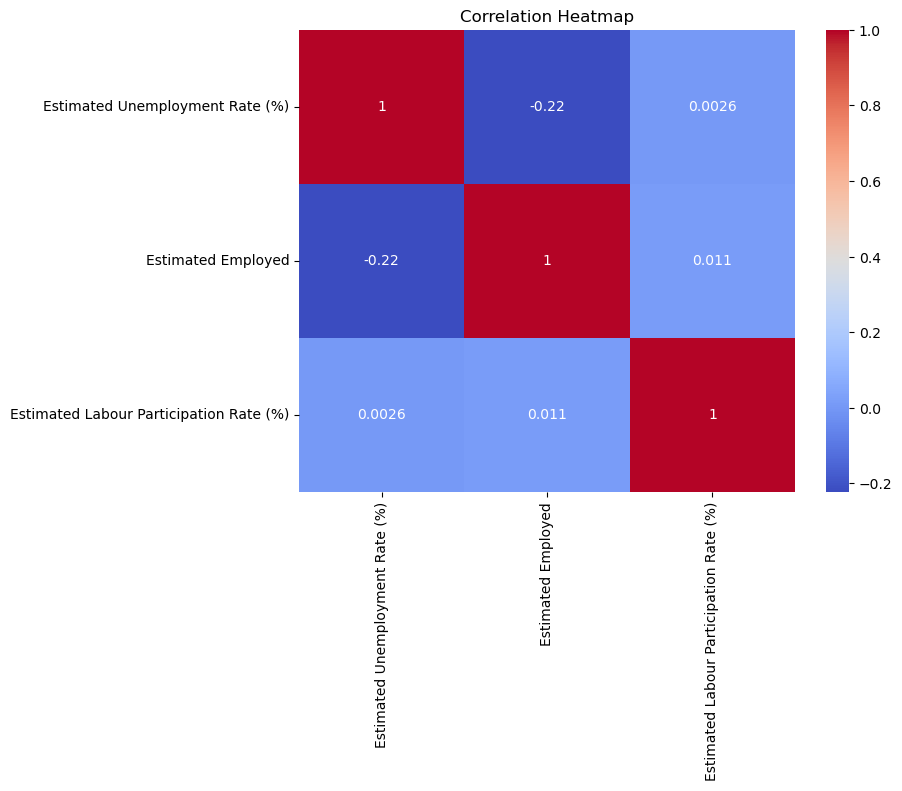


Average Unemployment Before Covid:
9.51

Average Unemployment During Covid:
17.77


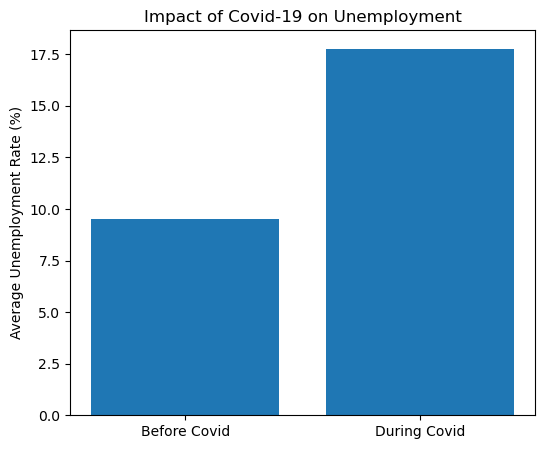

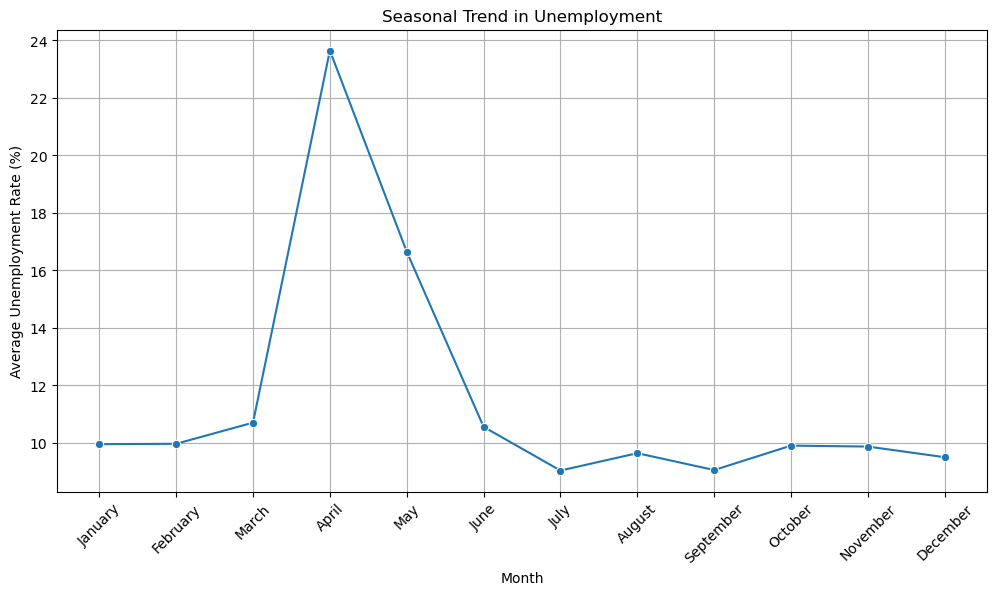

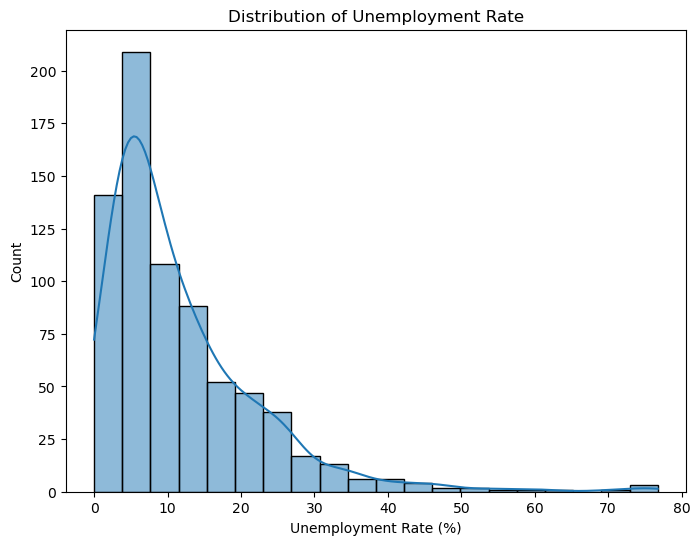


================ POLICY INSIGHTS ================

1. Covid-19 caused a significant rise in unemployment,
   indicating the importance of emergency employment programs.

2. Regions with consistently high unemployment should
   receive targeted economic support and industrial investment.

3. Skill development and vocational training programs
   can improve employability among unemployed populations.

4. Rural and urban unemployment differences suggest
   location-specific policies are necessary.

5. Seasonal fluctuations imply that temporary job schemes
   may help stabilize employment during high-unemployment periods.

6. Government support for MSMEs and startups can create
   additional employment opportunities.

7. Social protection measures such as unemployment benefits
   and income assistance can reduce economic hardships.



In [11]:
# ============================================================
# TASK 2: Unemployment Analysis with Python
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------
path = r"C:\Users\USER\Downloads\archive (2)\Unemployment in India.csv"

df = pd.read_csv(path)

# ------------------------------------------------------------
# Data Cleaning
# ------------------------------------------------------------
print("\nFirst 5 rows:")
print(df.head())

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Basic information
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


# ============================================================
# Exploratory Data Analysis
# ============================================================

# Average unemployment rate
avg_unemployment = df['Estimated Unemployment Rate (%)'].mean()

print("\nAverage Unemployment Rate:")
print(round(avg_unemployment,2), "%")

# Highest unemployment rate
highest_rate = df['Estimated Unemployment Rate (%)'].max()

print("\nHighest Unemployment Rate:")
print(round(highest_rate,2), "%")

# Region with highest average unemployment
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

print("\nTop 10 Regions with Highest Average Unemployment:")
print(region_avg.sort_values(ascending=False).head(10))


# ============================================================
# Visualization 1
# Overall Unemployment Trend
# ============================================================

monthly_unemployment = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
    .mean()
)

plt.figure(figsize=(14,6))
plt.plot(monthly_unemployment.index,
         monthly_unemployment.values,
         marker='o')

plt.title("Overall Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()


# ============================================================
# Visualization 2
# Top 10 Regions by Average Unemployment
# ============================================================

top_regions = region_avg.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_regions.values,
            y=top_regions.index)

plt.title("Top 10 Regions with Highest Average Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.show()


# ============================================================
# Visualization 3
# Rural vs Urban Comparison
# ============================================================

plt.figure(figsize=(8,6))
sns.boxplot(data=df,
            x='Area',
            y='Estimated Unemployment Rate (%)')

plt.title("Unemployment Rate: Rural vs Urban")
plt.xlabel("Area")
plt.ylabel("Unemployment Rate (%)")
plt.show()


# ============================================================
# Visualization 4
# Correlation Heatmap
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()


# ============================================================
# Covid-19 Impact Analysis
# ============================================================

covid_period = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-12-31')
]

pre_covid = df[df['Date'] < '2020-03-01']

print("\nAverage Unemployment Before Covid:")
print(round(pre_covid['Estimated Unemployment Rate (%)'].mean(),2))

print("\nAverage Unemployment During Covid:")
print(round(covid_period['Estimated Unemployment Rate (%)'].mean(),2))


# Visualization
pre_value = pre_covid['Estimated Unemployment Rate (%)'].mean()
covid_value = covid_period['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(6,5))

plt.bar(
    ['Before Covid', 'During Covid'],
    [pre_value, covid_value]
)

plt.ylabel("Average Unemployment Rate (%)")
plt.title("Impact of Covid-19 on Unemployment")
plt.show()


# ============================================================
# Seasonal Pattern Analysis
# ============================================================

df['Month'] = df['Date'].dt.month_name()

seasonal = (
    df.groupby('Month')
    ['Estimated Unemployment Rate (%)']
    .mean()
)

month_order = [
'January','February','March','April',
'May','June','July','August',
'September','October','November','December'
]

seasonal = seasonal.reindex(month_order)

plt.figure(figsize=(12,6))
sns.lineplot(x=seasonal.index,
             y=seasonal.values,
             marker='o')

plt.xticks(rotation=45)
plt.title("Seasonal Trend in Unemployment")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid()
plt.show()


# ============================================================
# Employment Distribution by Area
# ============================================================

plt.figure(figsize=(8,6))

sns.histplot(
    data=df,
    x='Estimated Unemployment Rate (%)',
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.show()


# ============================================================
# POLICY INSIGHTS
# ============================================================

print("\n================ POLICY INSIGHTS ================\n")

print("1. Covid-19 caused a significant rise in unemployment,")
print("   indicating the importance of emergency employment programs.")

print("\n2. Regions with consistently high unemployment should")
print("   receive targeted economic support and industrial investment.")

print("\n3. Skill development and vocational training programs")
print("   can improve employability among unemployed populations.")

print("\n4. Rural and urban unemployment differences suggest")
print("   location-specific policies are necessary.")

print("\n5. Seasonal fluctuations imply that temporary job schemes")
print("   may help stabilize employment during high-unemployment periods.")

print("\n6. Government support for MSMEs and startups can create")
print("   additional employment opportunities.")

print("\n7. Social protection measures such as unemployment benefits")
print("   and income assistance can reduce economic hardships.")

print("\n==================================================")